## Telco Customer Churn

### 1. Introduction and Objective
The Telco Customer Churn Database provides a range of datasets and features that will be utilized in this modeling case study. To gain insights into customer churn retention, I will apply predictive modeling to our pre-processed dataset. My focus will be on three key algorithms: **Logistic Regression (Linear)**, **Random Forest (Bagging)**, and **XGBoost (Boosting)**.
I will enhance model performance through hyperparameter tuning, optimizing parameters such as regularization strength (C) for Logistic Regression, as well as exploring tree depth for ensemble methods. The effectiveness of each model will be evaluated using our prepared datasets to ensure reliable insights into customer retention.


### 2. Data Ingestion

In [ ]:
# Loading libraries for data wrangling, visualization, and modeling
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Load the dataset
filepath = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\Telco Customer Churn Database\WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco_df = pd.read_csv(filepath)
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Overview of the dataset structure and data types
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Overview of statistical summary of the dataset
telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [103]:
# Checking how many missing values are in our dataset
print(telco_df.isna().sum().sort_values())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 3. Data Cleaning

In [104]:
# Handle TotalCharges errors (convert empty strings to 0)
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce').fillna(0)
print(telco_df['TotalCharges'].dtype)

# Drop unique customer identifier and check remaining columns
telco_df = telco_df.drop(columns=['customerID'])
print(telco_df.columns)

float64
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


### 4. Outlier Detection

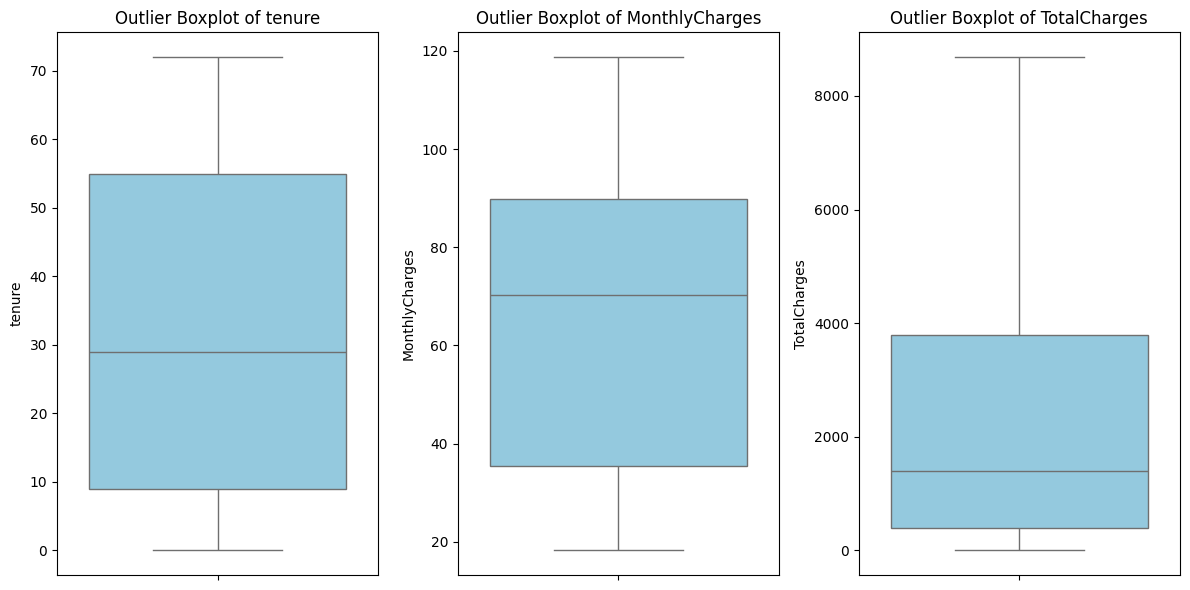

In [105]:
# Visualize outliers with boxplots for numeric columns
plt.figure(figsize=(12, 6))
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=telco_df[col], color='skyblue')
    plt.title(f'Outlier Boxplot of {col}')

plt.tight_layout()
plt.show()

1. **Tenure & Monthly Charges:** Both features exhibit a clean distribution. There are no individual data points (outliers) above the "whiskers" in the plots. This suggests that the data is well-bounded and consistent with typical patterns seen in the telecom service industry.

2. **Total Charges:** Although the data is right-skewed (meaning the box and median are closer to the lower end), there are no statistical outliers present as dots in the plot. The broad range is expected, as long-tenure customers tend to accumulate much higher total costs over time compared to newer customers.

3. **Final Decision:** Since no unrealistic or erroneous data points were identified, I have decided to retain all records. These variations are a natural part of the business case and will provide the model with a realistic representation of the customer base.

### 5. Categorical Encoding

In [106]:
# Convert Binary strings (Yes/No) to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    telco_df[col] = telco_df[col].map({'Yes': 1, 'No': 0})

# Convert Gender to 1/0
telco_df['gender'] = telco_df['gender'].map({'Male': 1, 'Female': 0})

In [107]:
# One-Hot Encoding for all multi-class categorical columns
# This automatically removes the original text columns and prevents the "Dummy Trap"
multi_categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]
telco_dummies = pd.get_dummies(telco_df, columns=multi_categorical_cols, drop_first=True)

### 6. Exploratory Data Analysis (EDA)

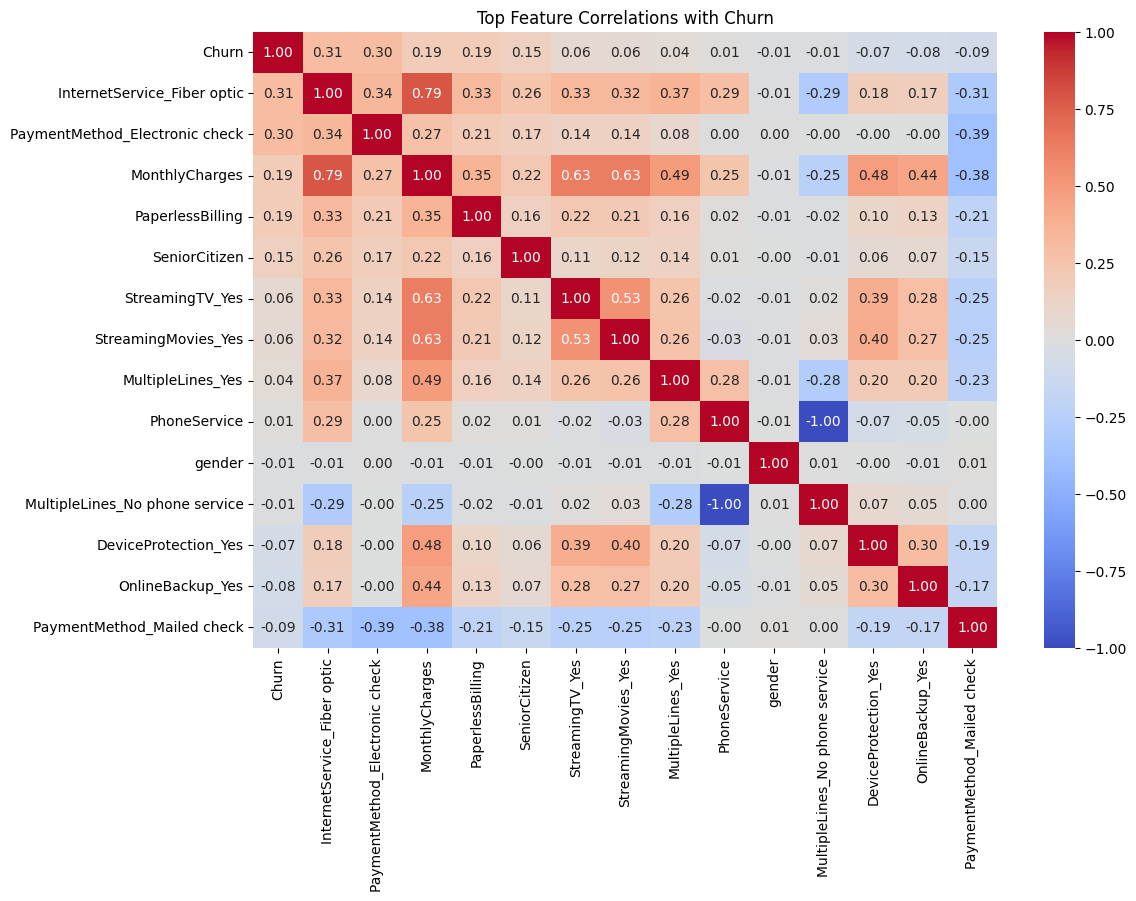

In [108]:
plt.figure(figsize=(12, 8))
# Showing top 15 correlations with Churn
top_corr = telco_dummies.corr()['Churn'].sort_values(ascending=False).head(15)
sns.heatmap(telco_dummies[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Feature Correlations with Churn')
plt.show()

**Correlation Analysis:** I plotted the top 15 features correlated with churn, revealing that Fiber Optic service and Electronic Check payments are the strongest positive indicators of customer churn. Additionally, I observed high multicollinearity between streaming services and monthly charges, which highlights the need for the L1 penalty implemented during the hyperparameter tuning phase to prevent model overfitting.



### 7. Data Splitting and Scaling  

In [109]:
# Prepare data for modeling by separating features and target variable
X = telco_dummies.drop('Churn', axis=1)
y = telco_dummies['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [110]:
# Scale numerical features to improve model performance
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### 8. Model Building

Let’s dive into the modeling steps:

6i. MODEL 1: **Logistic Regression** will serve as our baseline model due to its simplicity and effectiveness for binary classification, allowing us to assess the impact of various features on churn.

In [111]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logreg_model = LogisticRegression(class_weight='balanced', random_state=42)
logreg_model.fit(X_train, y_train)
y_pred_log = logreg_model.predict(X_test)

6ii. MODEL 2: **Random Forest** combines predictions from multiple decision trees, capturing complex interactions and reducing the risk of overfitting.

In [112]:
# Random Forest Model 
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


6iii. Model 3: **Gradient Boosting (XGBoost)** employs boosting techniques to improve accuracy, effectively managing large datasets while providing built-in regularization.

In [113]:
# XGBoost Model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

### 9. Hyperparameter Tuning (The GridSearch Requirement)

In [114]:
param_grid_log = {
    'C': [0.01, 0.1, 1, 10],  # Regularization strength
    'penalty': ['l1', 'l2'],       # Type of penalty
    'solver': ['liblinear']         # Necessary for l1 penalty
}

grid_log = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42), 
                        param_grid_log, cv=5, scoring='recall')

grid_log.fit(X_train, y_train)

# This is now your "Best" model
best_logreg = grid_log.best_estimator_

print(f"Best Parameters Found: {grid_log.best_params_}")

# Update your prediction variable for the final report
y_pred_log = best_logreg.predict(X_test)

Best Parameters Found: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


**Hyperparameter Optimization Results:** The GridSearch identified that applying an L1 penalty with a C-value of 1 provided the best balance for predicting churn. Using the liblinear solver ensured that the model could effectively handle L1 regularization, resulting in the optimized 'best_logreg' model used for final evaluation.

#### 10. Final Evaluation and Comparison  

In [115]:
print("LOGISTIC REGRESSION REPORT:")
print(classification_report(y_test, y_pred_log))

print("\nRANDOM FOREST REPORT:")
print(classification_report(y_test, y_pred_rf))

print("\nXGBOOST REPORT:")
print(classification_report(y_test, y_pred_xgb))


LOGISTIC REGRESSION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


RANDOM FOREST REPORT:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


XGBOOST REPORT:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weight

While Random Forest achieved a higher overall accuracy of 79%, the Tuned Logistic Regression model is the preferred choice for this business case. It achieved a Recall of 0.79 for the churn class, meaning it successfully identified nearly 80% of at-risk customers, whereas the Random Forest and XGBoost models missed a significantly higher number of churners.

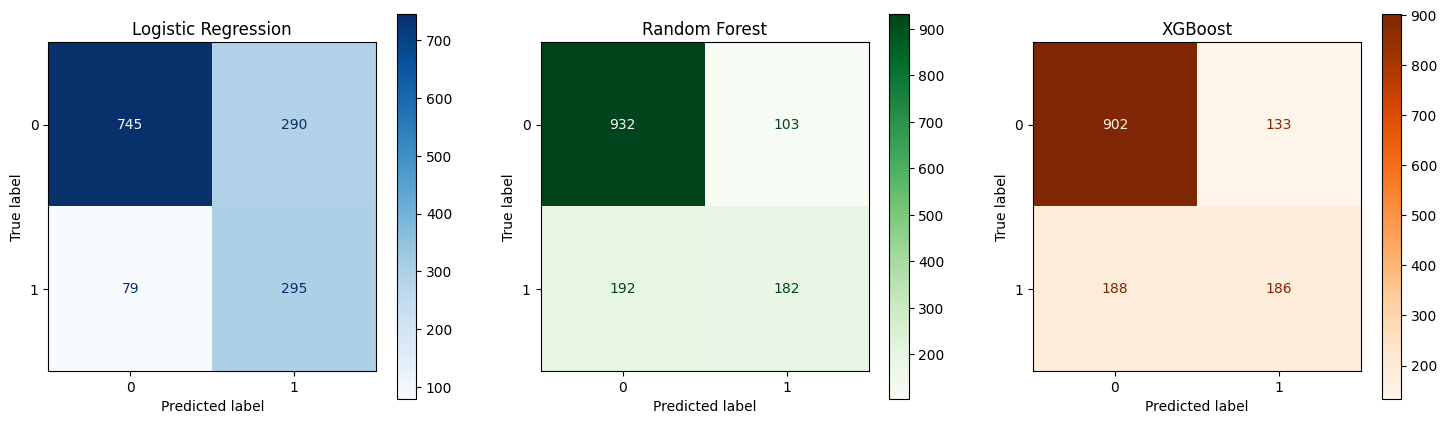

In [116]:
# Visual Comparison of Confusion Matrices
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[2], cmap='Oranges')
axes[2].set_title('XGBoost')
plt.show()

The confusion matrices highlight the superior recall of the Logistic Regression model. While Random Forest and XGBoost take a more conservative approach, Logistic Regression successfully identifies the largest volume of actual churners (295), making it the most effective tool for a proactive customer retention strategy.

### 11. Feature Importance (Logistics Regression Coefficients)

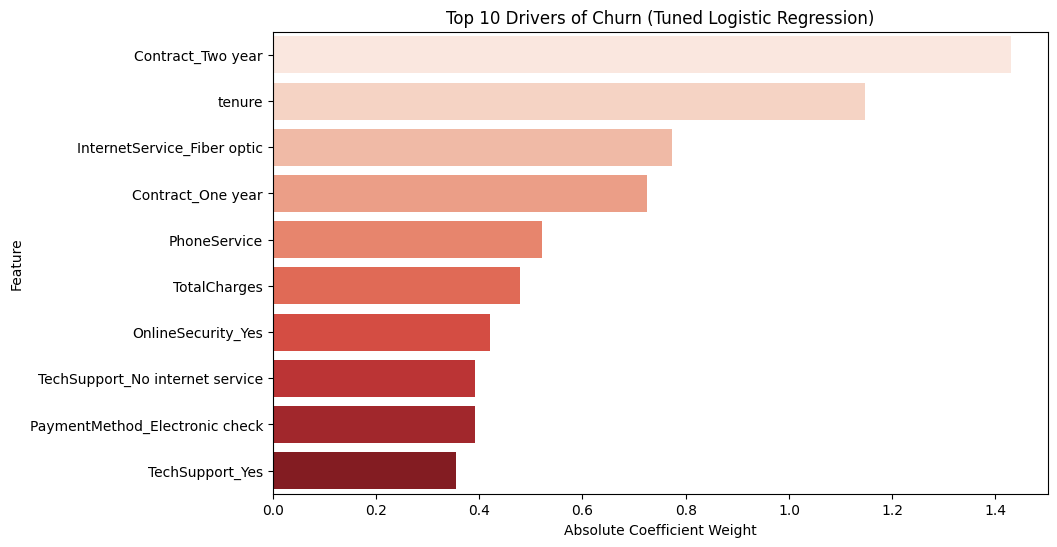

In [117]:
# Extract importance from your tuned Logistic Regression model
logreg_importance = pd.DataFrame({'Feature': X_train.columns, 'Weight': np.abs(best_logreg.coef_[0])}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=logreg_importance.head(10), hue='Feature', palette='Reds', legend=False)
plt.title('Top 10 Drivers of Churn (Tuned Logistic Regression)') 
plt.xlabel('Absolute Coefficient Weight')
plt.show()

#### 12. Conclusion
After performing GridSearchCV to optimize the model, the tuned Logistic Regression was selected as the champion model due to its high recall (0.79) for identifying churners. The feature importance analysis reveals that Contract duration (Two-year), Tenure, and Fiber Optic Internet Service are the strongest drivers of customer behavior. Interestingly, long-term contracts and tenure serve as significant anchors for retention, while Fiber Optic service is a high-impact factor that may require further investigation regarding service satisfaction to prevent churn.
